In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

In [40]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [41]:
PREFIX_PATH = "../.."
dtype="fp16"

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)

df_csr_gather = pd.read_csv(f"{PREFIX_PATH}/bench_results_csr_gather_{dtype}.csv")
df_csr_gather["S"] = "CSRGather"
add_stats_siso(df_csr_gather, 2)

df = pd.concat([df_copy, df_csr_gather])


/tmp/ipykernel_1784307/4231226972.py:1: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


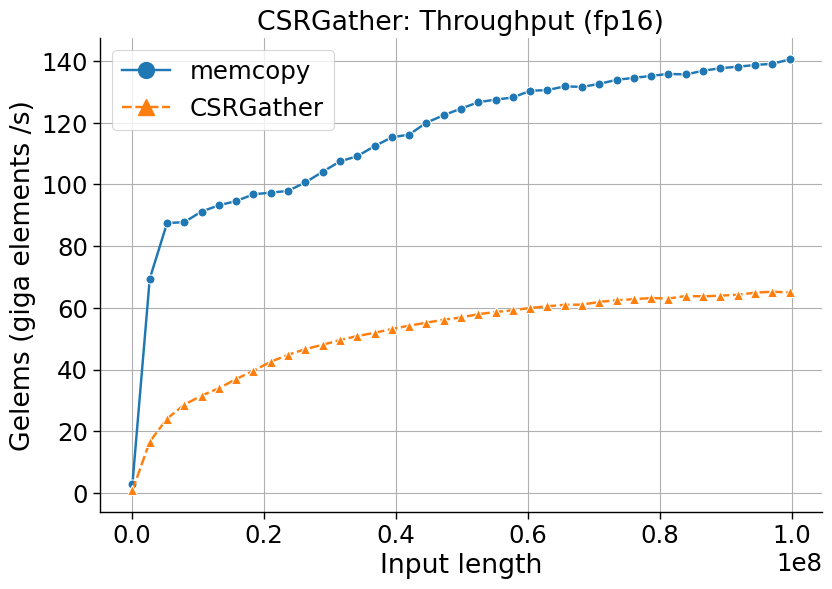

In [45]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"CSRGather: Throughput ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Gelems (giga elements /s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"csr_gather_{dtype}.png")
plt.show()
